In [15]:
benchmarks = {
    'FFT': 
    {
        256:    [7671, 7671, 7668, 7672, 7669, 7669, 7670, 7671, 7671, 7672],
        512:    [16734, 16734, 16737, 16737, 16736, 16732, 16739, 16586, 16738, 16738],
        1024:   [35033, 34716, 35027, 35030, 35035, 35030, 34689, 34717, 34738, 35019],
        2048:   [75133, 75509, 75057, 75358, 75091, 75810, 75725, 75090, 75787, 75539],
        4096:   [160928, 161192, 161047, 160656, 162035, 160677, 161565, 160617, 160955, 162041]
    },
    'Autocorrelation':
    {
        256:    [2231, 2229, 2231, 2230, 2230, 2230, 2229, 2230, 2230, 2230],
        512:    [4853, 4853, 4852, 4852, 4852, 4852, 4852, 4852, 4852, 4852],
        1024:   [10095, 10094, 10094, 10094, 10095, 10095, 10095, 10095, 10095, 10094],
        2048:   [20584, 20582, 20583, 20583, 20582, 20583, 20583, 20582, 20582, 20582],
        4096:   [41554, 41555, 41554, 41554, 41555, 41555, 41555, 41555, 41555, 41555]
    },
    'Matched Filtering':
    {
        256:    [2281, 2280, 2278, 2279, 2281, 2281, 2280, 2279, 2281, 2279],
        512:    [4993, 4993, 4993, 4993, 4992, 4993, 4993, 4993, 4993, 4993],
        1024:   [10416, 10416, 10417, 10418, 10417, 10416, 10416, 10417, 10415, 10416],
        2048:   [21261, 21259, 21260, 21259, 21260, 21260, 21261, 21260, 21260, 21260],
        4096:   [42969, 42970, 42969, 42969, 42969, 42970, 42969, 42970, 42969, 42970]
    },
    'Sync Detection':
    {
        256:    [117, 117, 117, 117, 117, 117, 118, 117, 118, 118],
        512:    [230, 229, 228, 229, 230, 229, 229, 229, 230, 230],
        1024:   [452, 450, 451, 450, 451, 451, 452, 452, 451, 452],
        2048:   [893, 891, 893, 893, 893, 892, 892, 893, 893, 892],
        4096:   [1779, 1779, 1778, 1779, 1779, 1777, 1779, 1778, 1778, 1778]
    }
}

fs = 1637090

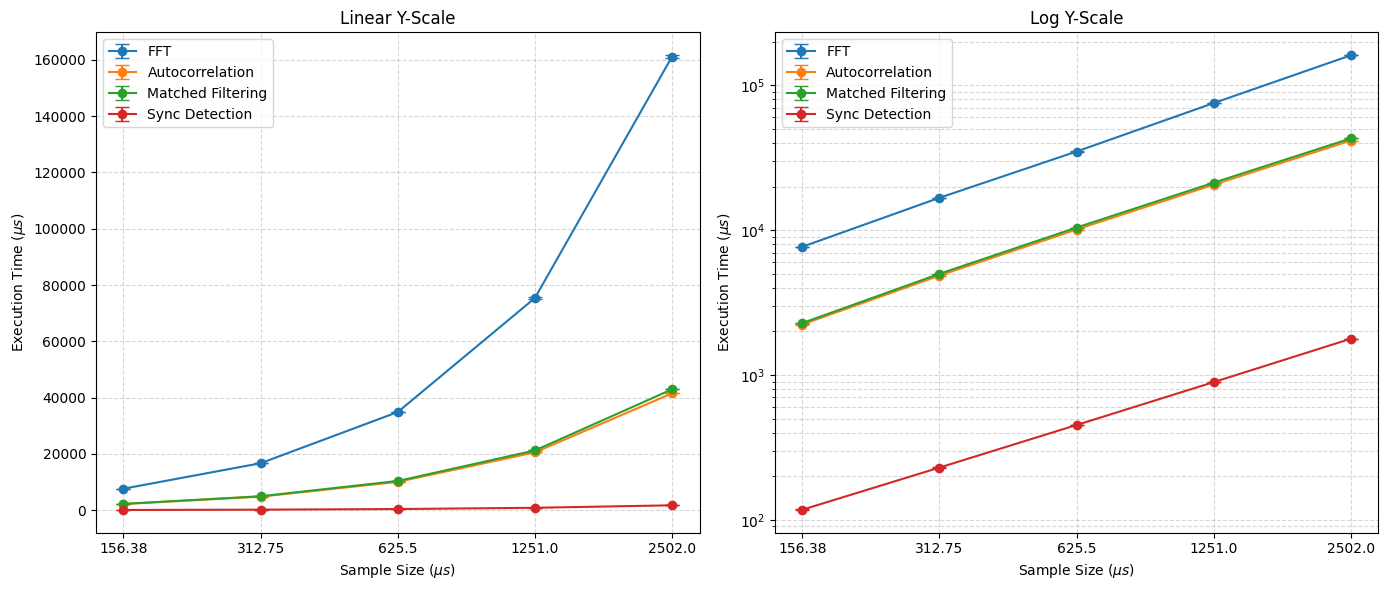

In [25]:
import matplotlib.pyplot as plt
import numpy as np

sizes = sorted(benchmarks['FFT'].keys())
times = [val / fs * 1e6 for val in sizes]
algos = list(benchmarks.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, scale in enumerate(['linear', 'log']):
    ax = axes[i]
    for algo in algos:
        means = [np.mean(benchmarks[algo][s]) for s in sizes]
        stds = [np.std(benchmarks[algo][s]) for s in sizes]
        ax.errorbar(times, means, yerr=stds, label=algo, marker='o', capsize=5)

    ax.set_xscale('log', base=2)
    ax.set_yscale(scale)
    ax.set_xticks(times)
    ax.set_xticklabels([str(round(s, 2)) for s in times])
    ax.set_xlabel('Sample Size ($\\mu s$)')
    ax.set_ylabel('Execution Time ($\\mu s$)')
    ax.set_title(f'{scale.capitalize()} Y-Scale')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()